# Trabajo Practico de Análisis de Datos - CEIA

Integrantes:
- Yoharlyn Alvarez
- Sebastián Aragones
- Luis Paredes

# Consigna

- Consiga: Disponible en [Notion](https://www.notion.so/mis-notas/Trabajo-Practico-35525f24dbe28028a94fc41adfb1e27e?source=copy_link)

- **Fecha de entrega**: La presentación se debe entregar como máximo el día martes 16/6/2026
- Diapositivas: Antes de la clase 8 les compartiremos una presentación de Google Slides para que peguen
la información resumida en 5 diapositivas como máximo (pueden ser 5 + la carátula).
- Repositorio del codigo: [Github](https://github.com/LuisParedes1/TP-CEIA-Analisis-de-datos)

# Full TMDB Movies Dataset 2024
## Analisis Exploratorio de los datos
Dataset: [Full TMDB Movies Dataset 2024](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies)

In [ ]:
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import numpy as np

directory_path: str = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

# Busco los archivos guardados en directory_path='/kaggle/input/tmdb-movies-dataset-2023-930k-movies/'
csv_files = [f for f in os.listdir(directory_path) if f.endswith('.csv')]

# Leo '/kaggle/input/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv'
df = pd.read_csv(os.path.join(directory_path, csv_files[0]))

df.head()

Using Colab cache for faster access to the 'tmdb-movies-dataset-2023-930k-movies' dataset.


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [ ]:
df.shape

(1439073, 24)

In [ ]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1439073 entries, 0 to 1439072
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1439073 non-null  int64  
 1   title                 1439054 non-null  object 
 2   vote_average          1439073 non-null  float64
 3   vote_count            1439073 non-null  int64  
 4   status                1439073 non-null  object 
 5   release_date          1113912 non-null  object 
 6   revenue               1439073 non-null  int64  
 7   runtime               1439073 non-null  int64  
 8   adult                 1439073 non-null  bool   
 9   backdrop_path         355654 non-null   object 
 10  budget                1439073 non-null  int64  
 11  homepage              147633 non-null   object 
 12  imdb_id               672379 non-null   object 
 13  original_language     1439073 non-null  object 
 14  original_title        1439054 non-

In [ ]:
df.iloc[0]

,0
id,27205
title,Inception
vote_average,8.364
vote_count,34495
status,Released
release_date,2010-07-15
revenue,825532764
runtime,148
adult,False
backdrop_path,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg


Iniciamos con la identificación de datos faltantes e incorrectos para que nos ayude a plantear un problema, teniendo una cantidad relevante de datos que contribuyan al entrenamiento del modelo.

In [ ]:

df.isna().sum()

,0
id,0
title,19
vote_average,0
vote_count,0
status,0
release_date,325161
revenue,0
runtime,0
adult,0
backdrop_path,1083419


In [ ]:
df.isna().mean().round(4)*100

,0
id,0.00
title,0.00
vote_average,0.00
vote_count,0.00
status,0.00
release_date,22.60
revenue,0.00
runtime,0.00
adult,0.00
backdrop_path,75.29


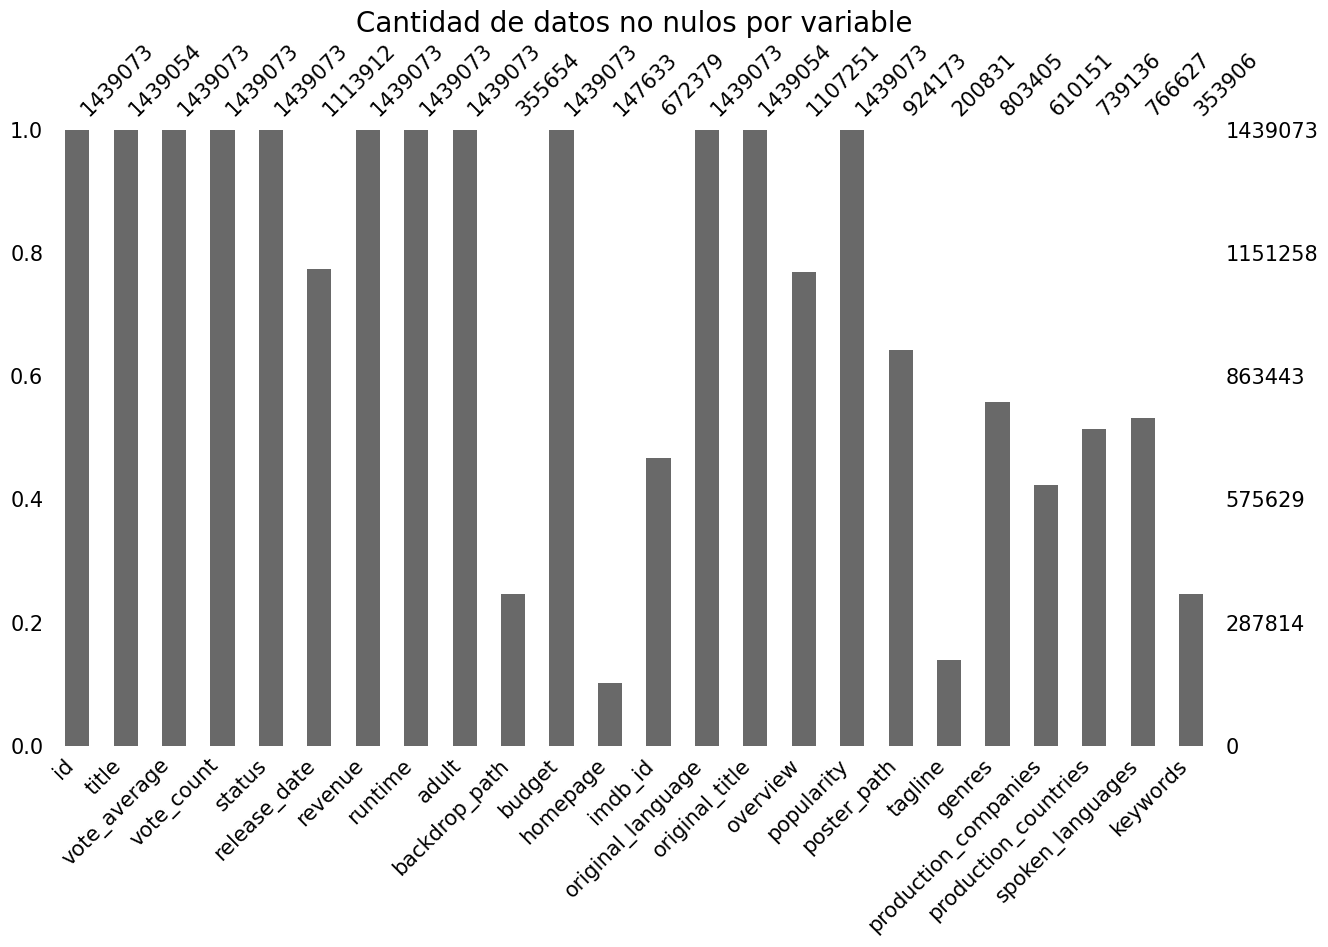

In [ ]:
msno.bar(df, fontsize=15, figsize=(15,8))
plt.title("Cantidad de datos no nulos por variable", fontsize=20)
plt.show()

<Axes: >

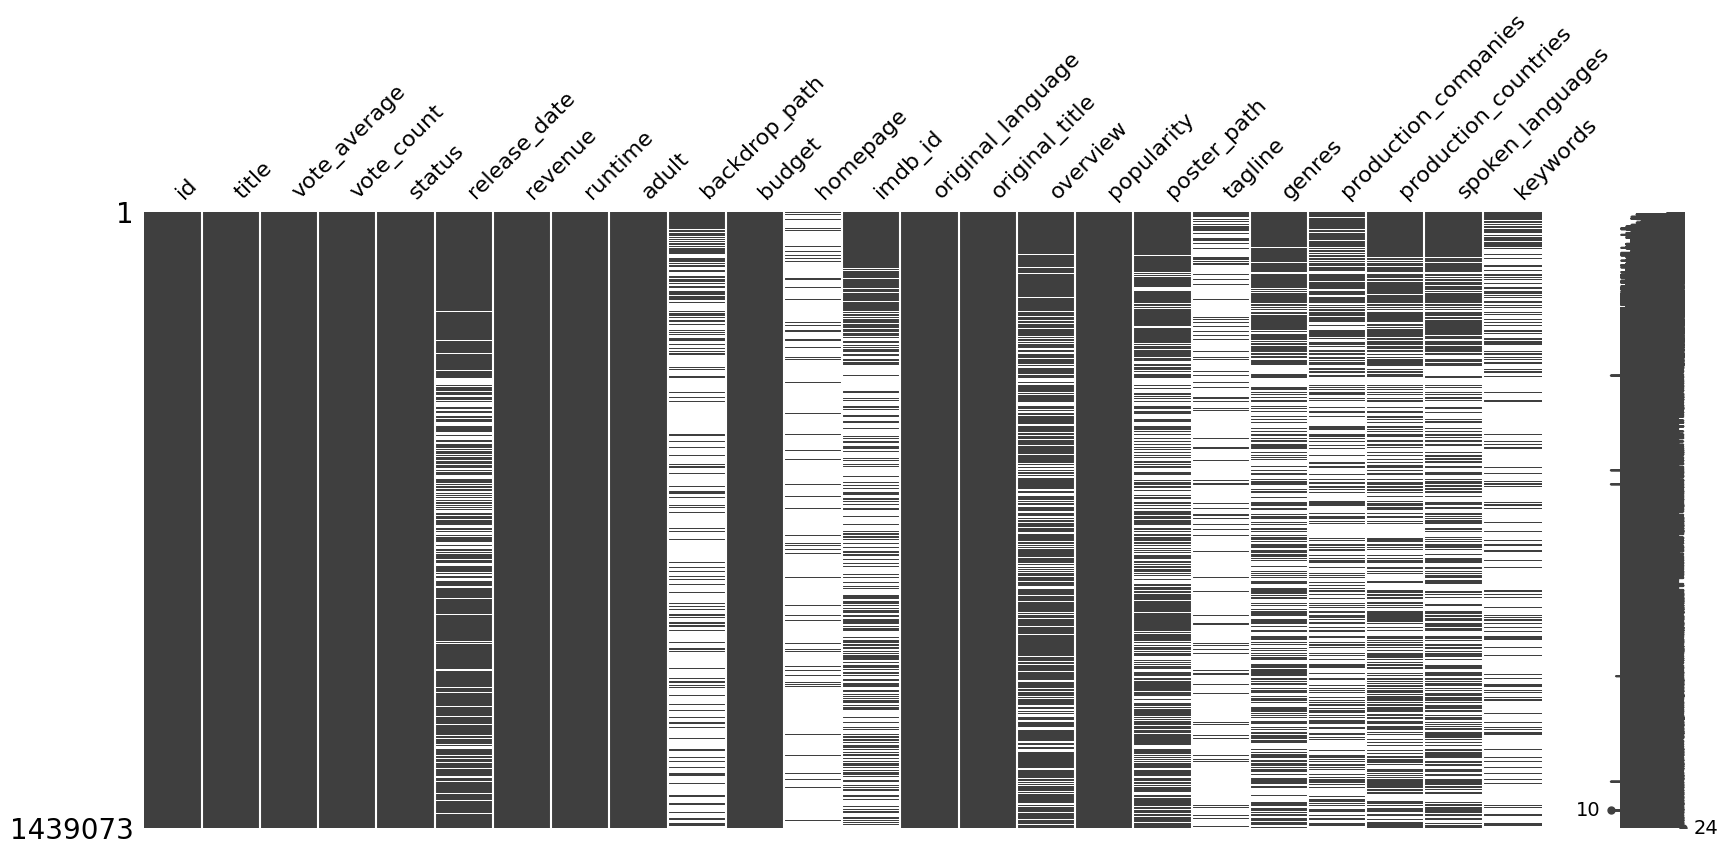

In [ ]:
msno.matrix(df, figsize=(20,8))

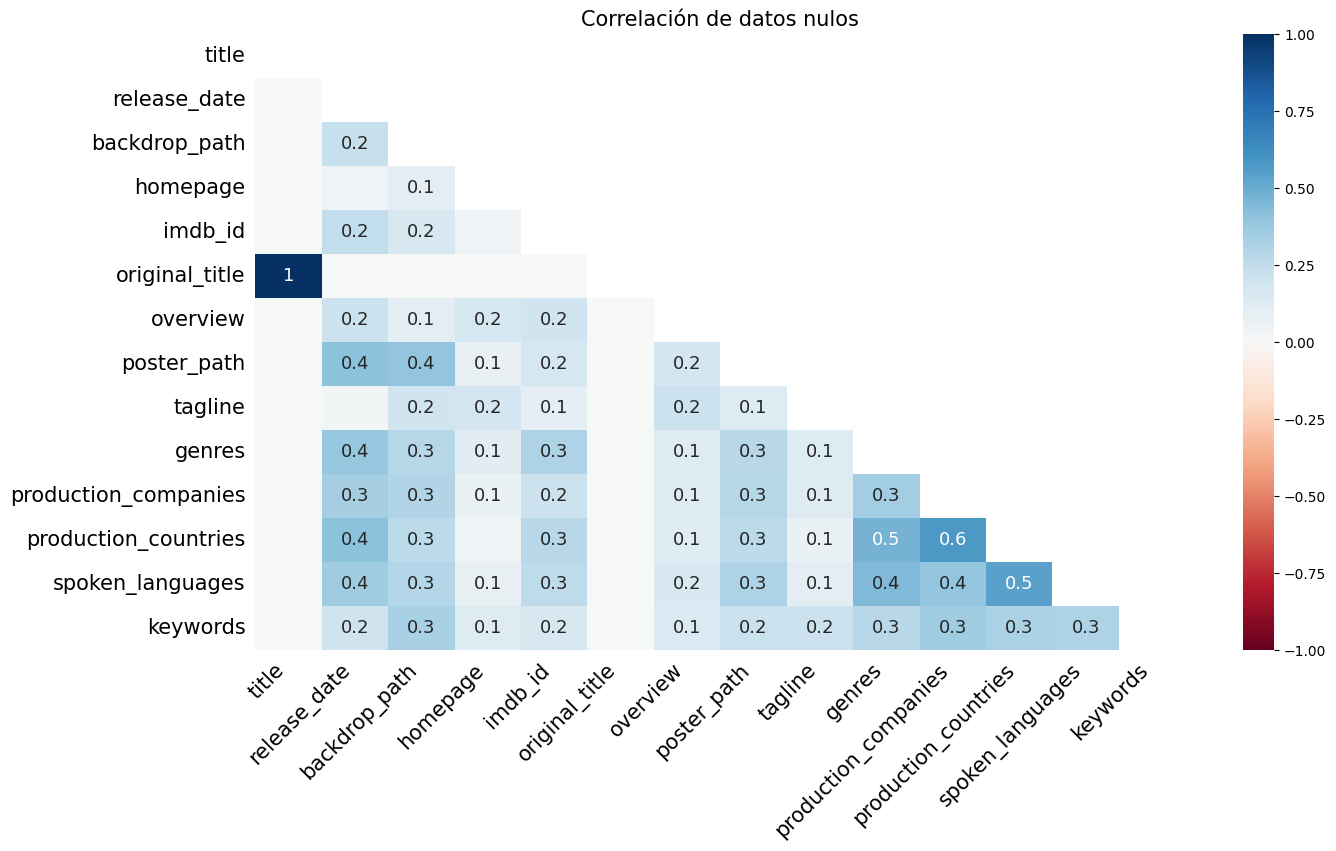

In [ ]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

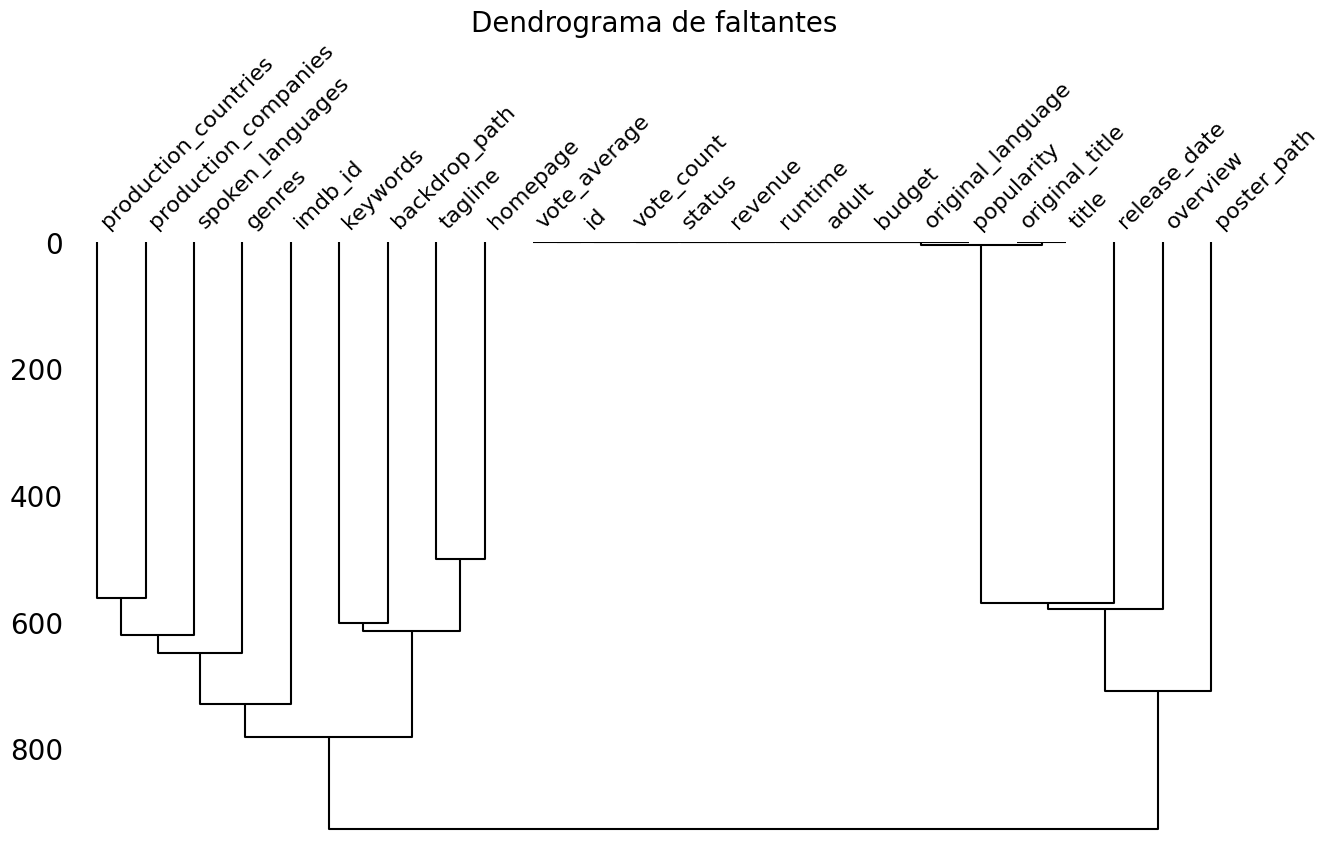

In [ ]:
msno.dendrogram(df, figsize=(15,8))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

In [ ]:
status_counts = df['status'].value_counts()
status_counts

,count
status,
Released,1386339
In Production,23782
Post Production,15881
Planned,11883
Rumored,815
Canceled,373


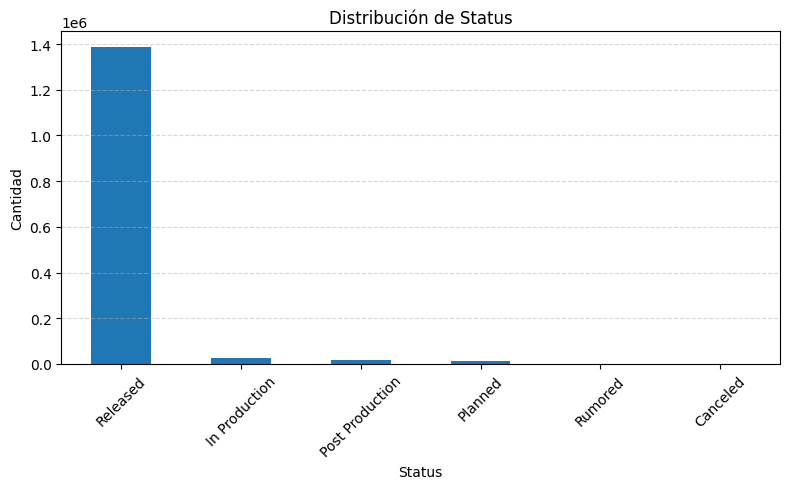

In [ ]:
plt.figure(figsize=(8, 5))
status_counts.plot(kind='bar')

plt.title('Distribución de Status')
plt.xlabel('Status')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
df_release_date_null = df[df['release_date'].isna()]
release_date_null_status_counts = df_release_date_null['status'].value_counts()
release_date_null_status_counts

,count
status,
Released,294963
Post Production,10707
Planned,10119
In Production,8250
Rumored,767
Canceled,355


In [ ]:
df['format_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['format_date'].dt.year.astype('Int64')

before_2000 = df[df['year'] < 2000]          # valid dates earlier than 2000
n_nulls = before_2000['budget'].isna().sum()  # swap 'budget' for your column

print(n_nulls)

In [ ]:
df['format_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['format_date'].dt.year.astype('Int64')

df_format = df[(df['release_date'].isna()) & (df['year'] < 2000)]

df_format.shape

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,format_date,year
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",2010-07-15,2010
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",2014-11-05,2014
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",2008-07-16,2008
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",2009-12-15,2009
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",2012-04-25,2012


Una de las columnas que utilizaremos para el problema que queremos plantear es **release_date** y por lo que vemos el **22.59%** de los datos tiene null en el valor de dicha columna.

Por lo que observamos, no encontramos un patrón para la ausencia de este valor. Inicialmente habíamos creído que las películas que no tenían este valor tendrían un valor de **status** diferente a "**released**", por lo cual no tendría una fecha establecida para su lanzamiento. Pero observamos algo completamente diferente a esto, la mayor cantidad de películas sin fecha de lanzamiento tienen status **released**. Por lo cual creemeos que para un gran porcentaje de las películas el tipo de causa de datos faltantes es **MCAR** y para un bajo porcentaje (las películas que aún no han salido) es de tipo **estructural**.

In [ ]:
df['genres'].value_counts()

,count
genres,
Documentary,164283
Drama,124843
Comedy,66792
Animation,37060
Music,30019
...,...
"Drama, Science Fiction, Action, Animation",1
"Animation, Science Fiction, Fantasy, Action, Comedy",1
"Science Fiction, Fantasy, Animation, Action, TV Movie",1


Observamos que en varias películas no posee un sólo género sino un listado de géneros. Más adelante tendremos que hacer un tratmiento a la muestra de datos para resolver esto.

In [ ]:
unique_genres = (
    df['genres']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .unique()
)

print(len(unique_genres))

19


In [ ]:
unique_genres

array(['Action', 'Science Fiction', 'Adventure', 'Drama', 'Crime',
       'Thriller', 'Fantasy', 'Comedy', 'Romance', 'Western', 'Mystery',
       'War', 'Animation', 'Family', 'Horror', 'Music', 'History',
       'TV Movie', 'Documentary'], dtype=object)

In [ ]:
df['adult'].value_counts()

,count
adult,
False,1296341
True,142732


In [ ]:
df['production_companies'].value_counts()

,count
production_companies,
Evil Angel,3182
ONF | NFB,2450
BBC,2403
Metro-Goldwyn-Mayer,2051
Columbia Pictures,1959
...,...
"8bit, Bandai Namco Filmworks, Magic Capsule, Sony Music Solutions, Bandai Spirits, Kodansha, MICRO MAGAZINE, Bandai Namco Music Live, Nippon BS Broadcasting, ADK Marketing Solutions, Nippon Television Network Corporation, Lantis",1
"Euskal Média S.A., La Sept Cinéma, Smile Production",1
Gar Film,1


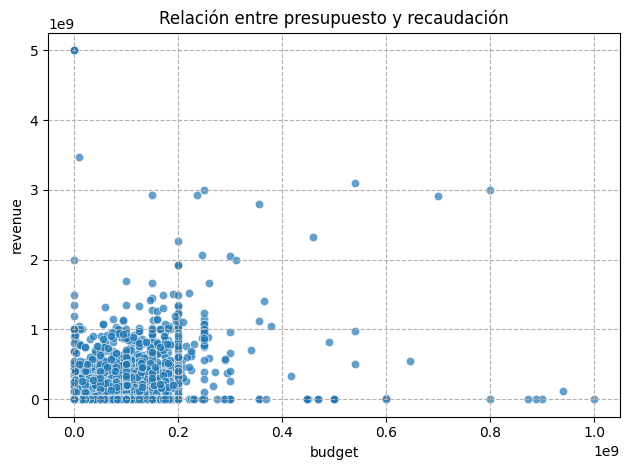

In [ ]:
sns.scatterplot(data=df, x='budget', y='revenue', alpha=0.7)
plt.grid(ls='--')
plt.title('Relación entre presupuesto y recaudación')
plt.tight_layout()
plt.show()

In [ ]:
min_budget = df['budget'].min()
max_budget = df['budget'].max()

print("Valor mínimo de presupuesto:", min_budget)
print("Valor máximo de presupuesto:", max_budget)

Valor mínimo de presupuesto: 0
Valor máximo de presupuesto: 999999999


In [ ]:
min_revenue = df['revenue'].min()
max_revenue = df['revenue'].max()

print("Valor mínimo de recaudación:", min_revenue)
print("Valor máximo de recaudación:", max_revenue)

Valor mínimo de recaudación: -12
Valor máximo de recaudación: 4999999999


In [ ]:
valid_budget_revenue = (df['budget'] > 0) & (df['revenue'] > 0)

valid_budget_revenue_count = valid_budget_revenue.sum()
valid_budget_revenue_percentage = valid_budget_revenue.mean() * 100

print("Cantidad de películas con presupuesto y recaudación mayores a 0:", valid_budget_revenue_count)
print(f"Porcentaje de películas con presupuesto y recaudación mayores a 0: {valid_budget_revenue_percentage:.2f}%")

Cantidad de películas con presupuesto y recaudación mayores a 0: 17613
Porcentaje de películas con presupuesto y recaudación mayores a 0: 1.22%


El problema inicial que que queríamos plantear estaba relacionado a identificar el éxito de una película en base a las ganancias que obtuvo, considerando que una película se considera financieramente exitosa cuando el revenue dupica el budget.

A pesar de que no existen valores nulos para estos campos, observamos que sí existen numerosas películas con valores 0 para algunos de estos campos.

De todo el dataset apenas un 1.22% posee el valor de ambas columnas.

Por esta razón no vemos factible continuar con este problema y buscamos seguir midiendo el éxito de la película pero en base a la votación.

In [ ]:
min_budget = df['popularity'].min()
max_budget = df['popularity'].max()

print("Valor mínimo de presupuesto:", min_budget)
print("Valor máximo de presupuesto:", max_budget)

Valor mínimo de presupuesto: 0.0
Valor máximo de presupuesto: 2994.357


In [ ]:
valid_popularity = (df['popularity'] > 0)

valid_popularity_count = valid_popularity.sum()
valid_popularity_percentage = valid_popularity.mean() * 100

print("Cantidad de películas con votación:", valid_popularity_count)
print(f"Porcentaje de películas con votación: {valid_popularity_percentage:.2f}%")

Cantidad de películas con votación: 1191235
Porcentaje de películas con votación: 82.78%


In [ ]:
min_vote_count = df['vote_count'].min()
max_vote_count = df['vote_count'].max()

print("Valor mínimo de cantidad de votos:", min_vote_count)
print("Valor máximo de cantidad de votos:", max_vote_count)

Valor mínimo de cantidad de votos: 0
Valor máximo de cantidad de votos: 34495


In [ ]:
min_vote_average = df['vote_average'].min()
max_vote_average = df['vote_average'].max()

print("Valor mínimo del promedio de votación:", min_vote_average)
print("Valor máximo del promedio de votación:", max_vote_average)

Valor mínimo del promedio de votación: 0.0
Valor máximo del promedio de votación: 10.0


In [ ]:
valid_votes = (df['vote_count'] > 0) & (df['vote_average'] > 0)

valid_votes_count = valid_votes.sum()
valid_votes_percentage = valid_votes.mean() * 100

print("Cantidad de películas con votación:", valid_votes_count)
print(f"Porcentaje de películas con votación: {valid_votes_percentage:.2f}%")

Cantidad de películas con votación: 358344
Porcentaje de películas con votación: 24.90%


In [ ]:
df_valid_movies = df[valid_votes]

In [ ]:
df_valid_movies.isna().sum()

,0
id,0
title,1
vote_average,0
vote_count,0
status,0
release_date,8883
revenue,0
runtime,0
adult,0
backdrop_path,172915


In [ ]:
df_valid_movies = df_valid_movies.dropna(subset=['release_date', 'genres'])

In [ ]:
df_valid_movies.shape

(293272, 24)

In [ ]:
genres_encoded = (
    df_valid_movies["genres"]
    .fillna("")
    .str.replace(", ", ",", regex=False)
    .str.get_dummies(sep=",")
)

genres_encoded = genres_encoded.add_prefix("genre_")

df_valid_movies = (
    df_valid_movies
    .join(genres_encoded)
    .drop(columns=["genres"])
)

df_valid_movies.shape

(293272, 42)

In [ ]:
df_valid_movies.columns.tolist()

['id',
 'title',
 'vote_average',
 'vote_count',
 'status',
 'release_date',
 'revenue',
 'runtime',
 'adult',
 'backdrop_path',
 'budget',
 'homepage',
 'imdb_id',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'poster_path',
 'tagline',
 'production_companies',
 'production_countries',
 'spoken_languages',
 'keywords',
 'genre_Action',
 'genre_Adventure',
 'genre_Animation',
 'genre_Comedy',
 'genre_Crime',
 'genre_Documentary',
 'genre_Drama',
 'genre_Family',
 'genre_Fantasy',
 'genre_History',
 'genre_Horror',
 'genre_Music',
 'genre_Mystery',
 'genre_Romance',
 'genre_Science Fiction',
 'genre_TV Movie',
 'genre_Thriller',
 'genre_War',
 'genre_Western']

In [ ]:
df_valid_movies.head(10)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,0,0,0,0,0,1,0,0,0,0
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,0,0,0,0,0,1,0,0,0,0
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,0,0,0,0,0,0,0,1,0,0
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,0,0,0,0,0,1,0,0,0,0
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,0,0,0,0,0,1,0,0,0,0
5,293660,Deadpool,7.606,28894,Released,2016-02-09,783100000,108,False,/en971MEXui9diirXlogOrPKmsEn.jpg,...,0,0,0,0,0,0,0,0,0,0
6,299536,Avengers: Infinity War,8.255,27713,Released,2018-04-25,2052415039,149,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,...,0,0,0,0,0,1,0,0,0,0
7,550,Fight Club,8.438,27238,Released,1999-10-15,100853753,139,False,/hZkgoQYus5vegHoetLkCJzb17zJ.jpg,...,0,0,0,0,0,0,0,0,0,0
8,118340,Guardians of the Galaxy,7.906,26638,Released,2014-07-30,772776600,121,False,/uLtVbjvS1O7gXL8lUOwsFOH4man.jpg,...,0,0,0,0,0,1,0,0,0,0
9,680,Pulp Fiction,8.488,25893,Released,1994-09-10,213900000,154,False,/suaEOtk1N1sgg2MTM7oZd2cfVp3.jpg,...,0,0,0,0,0,0,0,1,0,0


Hicimos una limpieza y de todo el dataset, nos quedaremos sólo con 293255 películas que cuenta con una cantidad de votos mayor a 0 y además posee información de su fecha de lanzamiento y género.

In [ ]:
df_valid_movies.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,0,0,0,0,0,1,0,0,0,0
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,0,0,0,0,0,1,0,0,0,0
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,0,0,0,0,0,0,0,1,0,0
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,0,0,0,0,0,1,0,0,0,0
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
df_valid_movies.iloc[0]

,0
id,27205
title,Inception
vote_average,8.364
vote_count,34495
status,Released
release_date,2010-07-15
revenue,825532764
runtime,148
adult,False
backdrop_path,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg


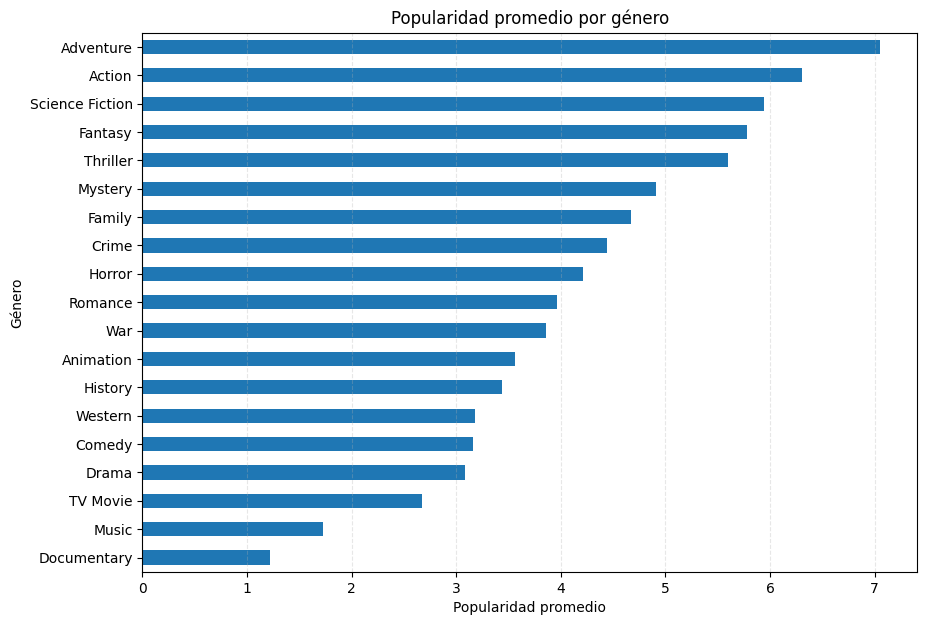

In [ ]:
genre_columns = [col for col in df_valid_movies.columns if col.startswith("genre_")]

popularity_by_genre = {}

for genre_col in genre_columns:
    genre_name = genre_col.replace("genre_", "")

    popularity_by_genre[genre_name] = df_valid_movies.loc[
        df_valid_movies[genre_col] == 1,
        "popularity"
    ].mean()

popularity_by_genre = (
    pd.Series(popularity_by_genre)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
popularity_by_genre.plot(kind="barh")
plt.xlabel("Popularidad promedio")
plt.ylabel("Género")
plt.title("Popularidad promedio por género")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()

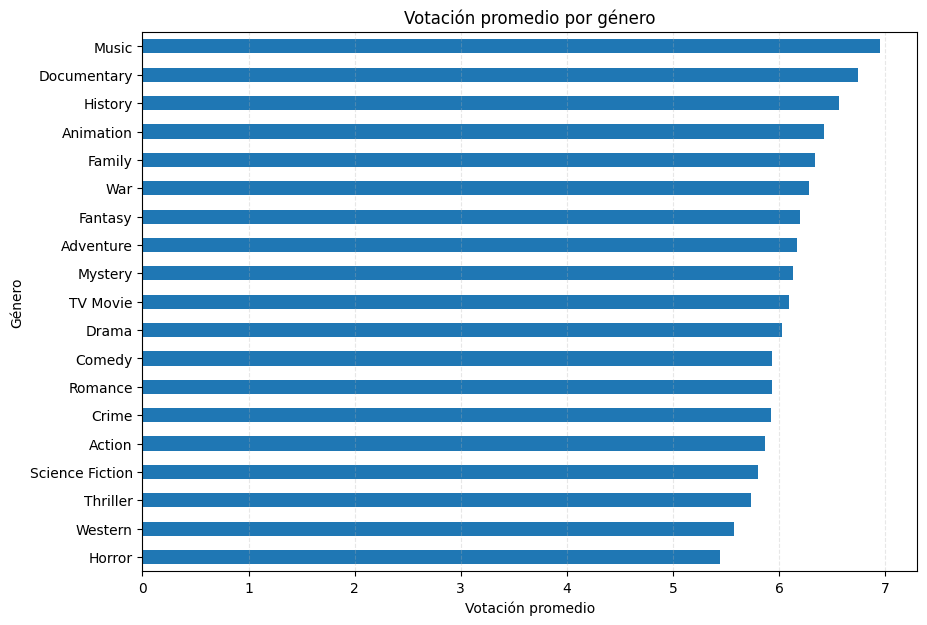

In [ ]:
vote_by_genre = {}

for genre_col in genre_columns:
    genre_name = genre_col.replace("genre_", "")

    vote_by_genre[genre_name] = df_valid_movies.loc[
        df_valid_movies[genre_col] == 1,
        "vote_average"
    ].mean()

vote_by_genre = (
    pd.Series(vote_by_genre)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
vote_by_genre.plot(kind="barh")
plt.xlabel("Votación promedio")
plt.ylabel("Género")
plt.title("Votación promedio por género")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.show()

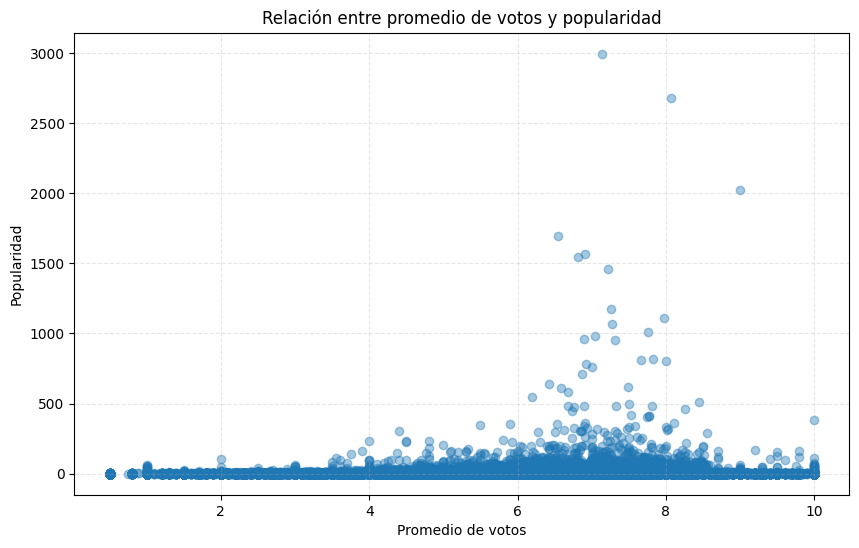

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_valid_movies["vote_average"],
    df_valid_movies["popularity"],
    alpha=0.4
)

plt.xlabel("Promedio de votos")
plt.ylabel("Popularidad")
plt.title("Relación entre promedio de votos y popularidad")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In [ ]:
min_vote_count = df_valid_movies['vote_count'].min()
max_vote_count = df_valid_movies['vote_count'].max()

print("Valor mínimo de cantidad de votos:", min_vote_count)
print("Valor máximo de cantidad de votos:", max_vote_count)

Valor mínimo de cantidad de votos: 1
Valor máximo de cantidad de votos: 34495


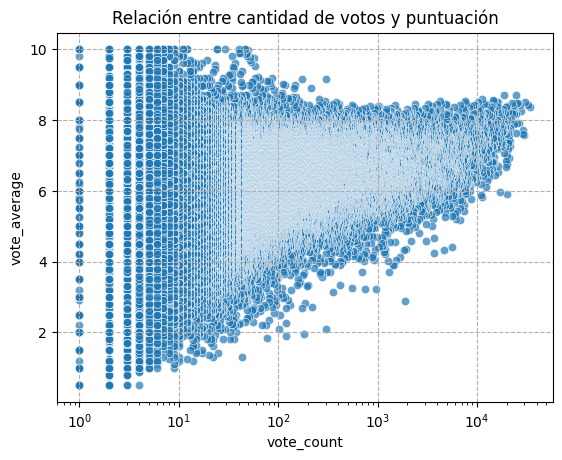

In [ ]:
sns.scatterplot(
    data=df_valid_movies,
    x='vote_count',
    y='vote_average',
    alpha=0.7
)

plt.xscale('log')
plt.grid(ls='--')
plt.title('Relación entre cantidad de votos y puntuación')
plt.show()

Con este gráfico podemos observar valores extremos en películas con pocos votos pero puntuaciones altas y la dispersión va disminuyendo a medida que aumenta la cantidad de votos.

Al momento de medir el éxito, sabemos que cuantos más votos recibe una película, más estable y confiable se vuelve su puntuación promedio. Por lo cual trabajaremos con la siguiente fórmula para el cálculo:

(vc / (vc+u)) * va + (u / (vc+u)) * m

vc = vote_count

va = vote_average

u = umbral mínimo de votos para considerar el rating confiable (típicamente un percentil alto de vote_count, ejemplo el 0.90).

m  = media global de vote_average del dataset

In [ ]:
df_valid_movies['release_date'].head(10)

,release_date
0,2010-07-15
1,2014-11-05
2,2008-07-16
3,2009-12-15
4,2012-04-25
5,2016-02-09
6,2018-04-25
7,1999-10-15
8,2014-07-30
9,1994-09-10


In [ ]:
df_valid_movies['release_date'] = pd.to_datetime(df_valid_movies['release_date'], errors='coerce')
df_valid_movies['release_month'] = df_valid_movies['release_date'].dt.month
df_valid_movies['release_month']

,release_month
0,7
1,11
2,7
3,12
4,4
...,...
359192,6
359193,11
359194,3
359195,7


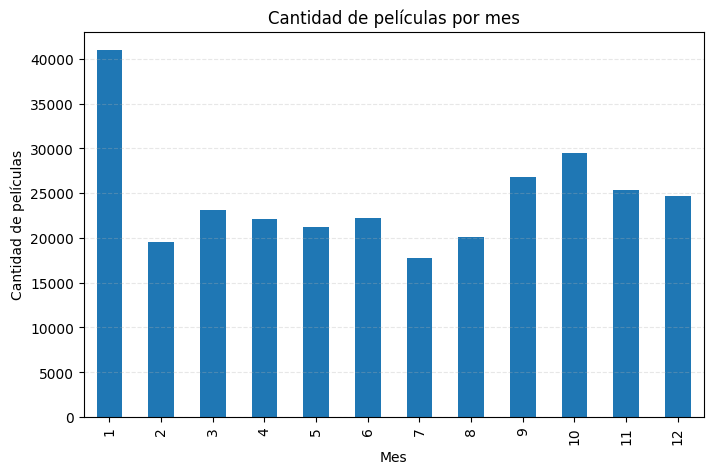

In [ ]:
month_counts = df_valid_movies['release_month'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
month_counts.plot(kind='bar')
plt.xlabel('Mes')
plt.ylabel('Cantidad de películas')
plt.title('Cantidad de películas por mes')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [ ]:
df_valid_movies['release_month'].mode()[0]

np.int32(1)

In [ ]:
df_valid_movies['release_year'] = df_valid_movies['release_date'].dt.year
df_valid_movies['release_year']

,release_year
0,2010
1,2014
2,2008
3,2009
4,2012
...,...
359192,2014
359193,2007
359194,1935
359195,2010


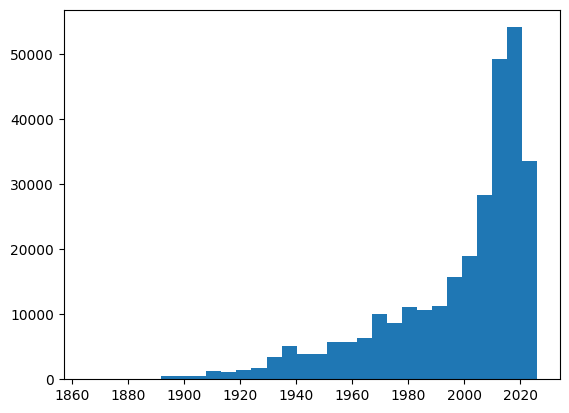

In [ ]:
plt.hist(df_valid_movies['release_year'], bins=30)
plt.show()

In [ ]:
df_valid_movies['release_year'].mode()[0]

np.int32(2019)

In [ ]:
min_release_year = df_valid_movies['release_year'].min()
max_release_year = df_valid_movies['release_year'].max()

print("Valor mínimo de año de lanzamiento:", min_release_year)
print("Valor máximo de año de lanzamiento:", max_release_year)

Valor mínimo de año de lanzamiento: 1865
Valor máximo de año de lanzamiento: 2026


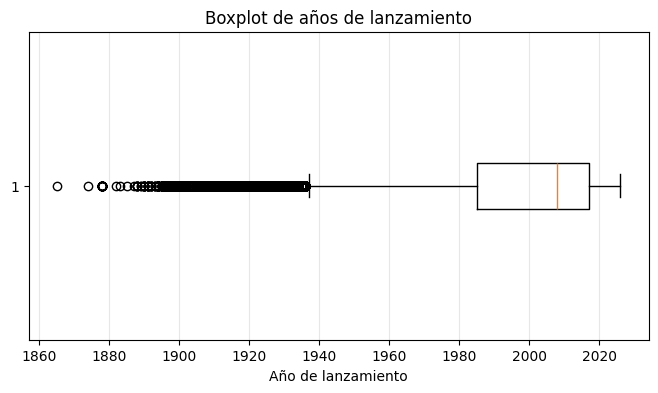

In [ ]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_valid_movies['release_year'], vert=False)
plt.xlabel('Año de lanzamiento')
plt.title('Boxplot de años de lanzamiento')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [ ]:
Q1 = df_valid_movies['release_year'].quantile(0.25)
Q3 = df_valid_movies['release_year'].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Límite inferior: {lower_bound}")
print(f"Límite superior: {upper_bound}")

outliers = df_valid_movies[
    (df_valid_movies['release_year'] < lower_bound) |
    (df_valid_movies['release_year'] > upper_bound)
]

print(f"Cantidad de outliers: {len(outliers)}")

Q1: 1985.0
Q3: 2017.0
IQR: 32.0
Límite inferior: 1937.0
Límite superior: 2065.0
Cantidad de outliers: 12226


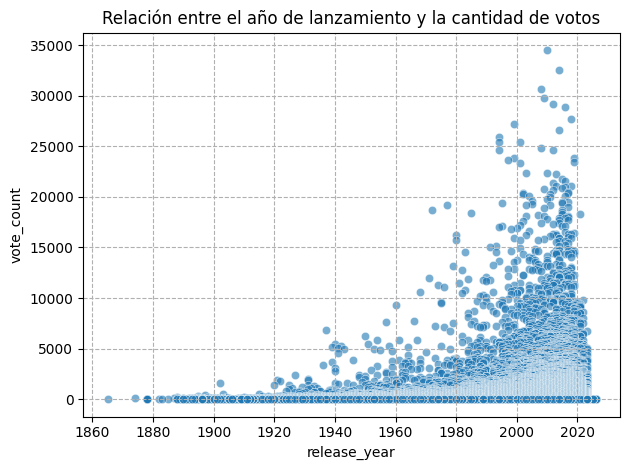

In [ ]:
sns.scatterplot(data=df_valid_movies, x='release_year', y='vote_count', alpha=0.6)
plt.grid(ls='--')
plt.title('Relación entre el año de lanzamiento y la cantidad de votos')
plt.tight_layout()
plt.show()

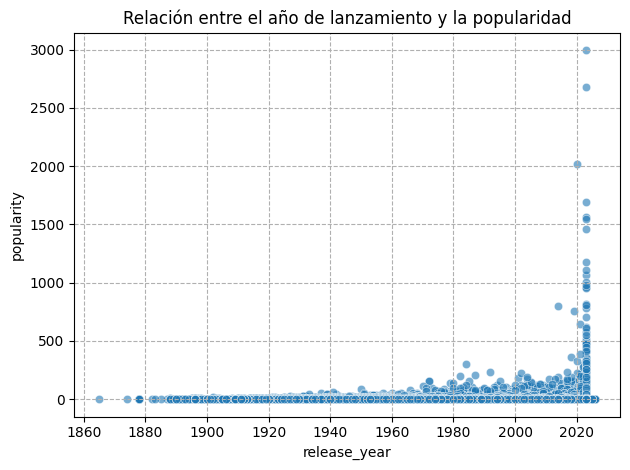

In [ ]:
sns.scatterplot(data=df_valid_movies, x='release_year', y='popularity', alpha=0.6)
plt.grid(ls='--')
plt.title('Relación entre el año de lanzamiento y la popularidad')
plt.tight_layout()
plt.show()

In [ ]:
u = df_valid_movies['vote_count'].quantile(0.90)
m = df_valid_movies['vote_average'].mean()

df_valid_movies['success_score'] = (
    (df_valid_movies['vote_count'] / (df_valid_movies['vote_count'] + u)) * df_valid_movies['vote_average'] +
    (u / (df_valid_movies['vote_count'] + u)) * m
)

df_valid_movies['success_score']

,success_score
0,8.360970
1,8.413717
2,8.508365
3,7.570714
4,7.707447
...,...
359192,6.065854
359193,6.065854
359194,5.980747
359195,6.023301


In [ ]:
threshold = df_valid_movies['success_score'].quantile(0.75)
threshold

np.float64(6.169902643007175)

In [ ]:
df_valid_movies['success_label'] = np.where(
    df_valid_movies['success_score'] >= threshold,
    'success',
    'no_success'
)

df_valid_movies['success_label']

,success_label
0,success
1,success
2,success
3,success
4,success
...,...
359192,no_success
359193,no_success
359194,no_success
359195,no_success


In [ ]:
success_by_year = (
    df_valid_movies
    .groupby(['release_year', 'success_label'])
    .size()
    .unstack(fill_value=0)
)

success_by_year.head()

success_label,no_success,success
release_year,,
1865,0,1
1874,1,0
1878,26,0
1882,1,0
1883,1,0


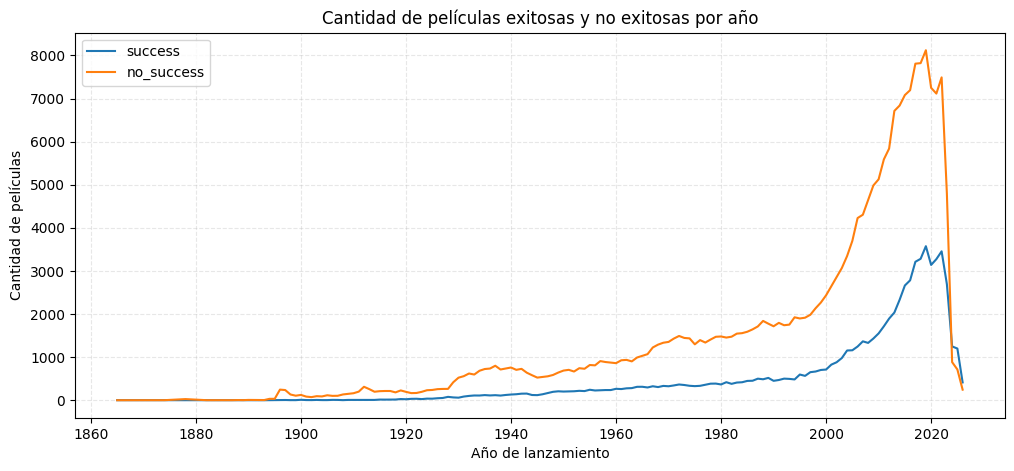

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(success_by_year.index, success_by_year['success'], label='success')
plt.plot(success_by_year.index, success_by_year['no_success'], label='no_success')

plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de películas')
plt.title('Cantidad de películas exitosas y no exitosas por año')
plt.legend()
plt.grid(ls='--', alpha=0.3)

plt.show()